# CREDIT DEFAULT PREDICTION

In [46]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import RocCurveDisplay
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from imblearn.combine import SMOTEENN
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import StackingClassifier


# Data Loading and Initial Inspections

First, we load the dataset and perform an inspection to understand the features and idetity missing values

In [2]:
df = pd.read_csv("csv/cs-training.csv")
df.head(5)

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [3]:

df = df.drop(columns=["Unnamed: 0"])

In [4]:
df.shape

(150000, 11)

In [5]:
df.columns

Index(['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'],
      dtype='str')

In [6]:
df.isnull().sum()

SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

We analyze how much those Nan represent.

In [7]:
(df.isnull().sum() / len(df)) * 100

SeriousDlqin2yrs                         0.000000
RevolvingUtilizationOfUnsecuredLines     0.000000
age                                      0.000000
NumberOfTime30-59DaysPastDueNotWorse     0.000000
DebtRatio                                0.000000
MonthlyIncome                           19.820667
NumberOfOpenCreditLinesAndLoans          0.000000
NumberOfTimes90DaysLate                  0.000000
NumberRealEstateLoansOrLines             0.000000
NumberOfTime60-89DaysPastDueNotWorse     0.000000
NumberOfDependents                       2.616000
dtype: float64

# Data Cleaning 

We found missing values in MonthlyIncome and NumberOfDependents. 

In Machine Learning Models cannot handle NaN values, so we applied data imputation.


In [8]:
df["MonthlyIncome"] = df["MonthlyIncome"].fillna(df["MonthlyIncome"].median())
df["NumberOfDependents"] = df["NumberOfDependents"].fillna(0)

In [9]:
df.isnull().sum()

SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64


MonthlyIncome was filled with the median to reduce the effect of outliers, while NumberOfDependents was filled with 0, assuming missing values indicate no reported dependents.
After this step, the dataset contains no missing values.

This approach corresponds to univariate imputation, a common and simple strategy for handling missing numerical data, and it is appropriate here since the proportion of missing values is relatively small.

### Target Variable

The variable SeriousDlqin2yrs is our target, as it represents the outcome that we want to predict. 

It indicates whether a person experienced a serious delinquency (default) within the next two years.

In [10]:
df["SeriousDlqin2yrs"].value_counts()

SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

<Axes: xlabel='SeriousDlqin2yrs'>

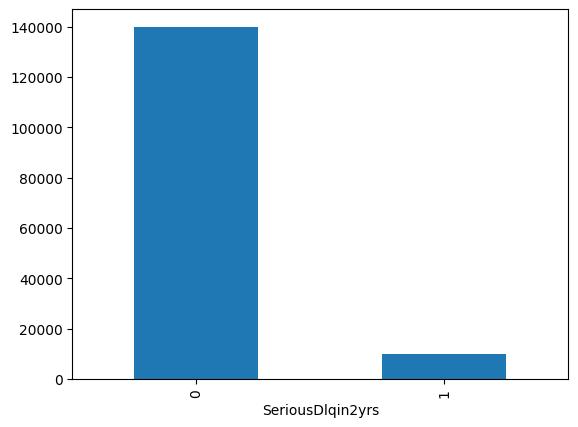

In [11]:
df["SeriousDlqin2yrs"].value_counts().plot(kind="bar")


The distribution of the target variable shows a clear class imbalance. Most observations correspond to class 0 (no delinquency), while a much smaller proportion corresponds to class 1 (serious delinquency). This imbalance is important because it can affect the performance of machine learning models, which may become biased toward predicting the majority class.

### Separate variables and target

In [43]:
X = df.drop("SeriousDlqin2yrs", axis=1)
y = df["SeriousDlqin2yrs"]

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [42]:
y_train.value_counts(normalize=True)
y_test.value_counts(normalize=True)

SeriousDlqin2yrs
0    0.933167
1    0.066833
Name: proportion, dtype: float64

The target variable SeriousDlqin2yrs is highly imbalanced.
Around 93% of the observations correspond to class 0 (no default) and 7% to class 1 (default).

To fix this, we use stratified splitting to keep the same proportion of defaults in both training and test sets.

# Logistic Regression Baselines

We start with simple models to see how the class imbalance affects the results.

### Baseline Model

The baseline logistic regression model is trained without applying any imbalance handling tecniques in order to evaluate how class imbalance affects model performance, specially for the minority class. 

=== BASELINE MODEL ===
              precision    recall  f1-score   support

           0       0.94      1.00      0.97     27995
           1       0.59      0.05      0.09      2005

    accuracy                           0.93     30000
   macro avg       0.76      0.52      0.53     30000
weighted avg       0.91      0.93      0.91     30000

ROC-AUC: 0.7112545658536281


/Users/anne/Desktop/3º Carrera/2 semestre/ML Avanzado/Repo/Advanced-Machine-Learning/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


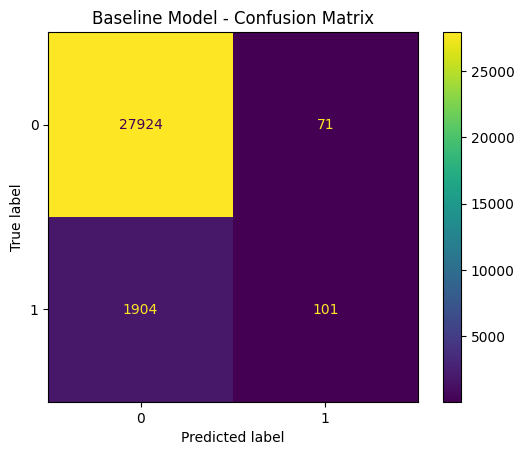

In [15]:
baseline_model = LogisticRegression(max_iter=1000, random_state=42)

baseline_model.fit(X_train, y_train)

# Predictions
y_pred_baseline = baseline_model.predict(X_test)
y_proba_baseline = baseline_model.predict_proba(X_test)[:, 1]

print("=== BASELINE MODEL ===")
print(classification_report(y_test, y_pred_baseline))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_baseline))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_baseline)
plt.title("Baseline Model - Confusion Matrix")
plt.show()


The baseline logistic regression model achieves high overall accuracy (around 93%), mainly because the dataset is highly imbalanced. However, the recall for the minority class (default) is very low (around 5%), meaning that the model fails to detect most default cases. This highlights the impact of class imbalance and motivates the use of techniques such as class weighting or oversampling.

### Balancing Strategies

At this stage our goal is to test different methods to help the model see the minority class better

#### Class Weighting

=== CLASS WEIGHT = BALANCED ===
              precision    recall  f1-score   support

           0       0.97      0.83      0.89     27995
           1       0.21      0.63      0.31      2005

    accuracy                           0.82     30000
   macro avg       0.59      0.73      0.60     30000
weighted avg       0.92      0.82      0.85     30000

ROC-AUC: 0.8045825960193284


/Users/anne/Desktop/3º Carrera/2 semestre/ML Avanzado/Repo/Advanced-Machine-Learning/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


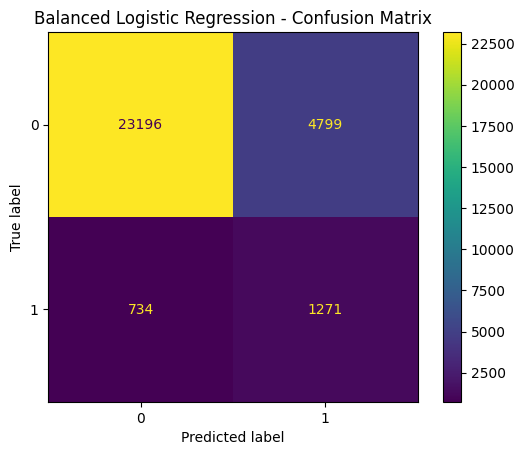

In [16]:
balanced_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced"
)

balanced_model.fit(X_train, y_train)

y_pred_balanced = balanced_model.predict(X_test)
y_proba_balanced = balanced_model.predict_proba(X_test)[:, 1]

print("=== CLASS WEIGHT = BALANCED ===")
print(classification_report(y_test, y_pred_balanced))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_balanced))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_balanced)
plt.title("Balanced Logistic Regression - Confusion Matrix")
plt.show()

A second logistic regression model was trained using class_weight="balanced" to penalize errors in the minority class more strongly. This helps the model pay more attention to default cases.


Using class_weight="balanced" significantly improves the model's ability to detect the minority class (default). The recall for class 1 increases substantially compared to the baseline model, meaning that more default cases are correctly identified. However, this improvement comes at the cost of an increase in false positives and a lower overall accuracy. This trade-off is common when dealing with imbalanced datasets.

#### SMOTE

In [17]:
#Apply SMOTE ONLY to training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Original distribution in y_train:")
print(y_train.value_counts())

print("\nDistribution after SMOTE:")
print(y_train_smote.value_counts())

Original distribution in y_train:
SeriousDlqin2yrs
0    111979
1      8021
Name: count, dtype: int64

Distribution after SMOTE:
SeriousDlqin2yrs
0    111979
1    111979
Name: count, dtype: int64


=== LOGISTIC REGRESSION + SMOTE ===
              precision    recall  f1-score   support

           0       0.96      0.69      0.80     27995
           1       0.13      0.63      0.21      2005

    accuracy                           0.69     30000
   macro avg       0.55      0.66      0.51     30000
weighted avg       0.91      0.69      0.76     30000

ROC-AUC: 0.7113254727086552


/Users/anne/Desktop/3º Carrera/2 semestre/ML Avanzado/Repo/Advanced-Machine-Learning/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


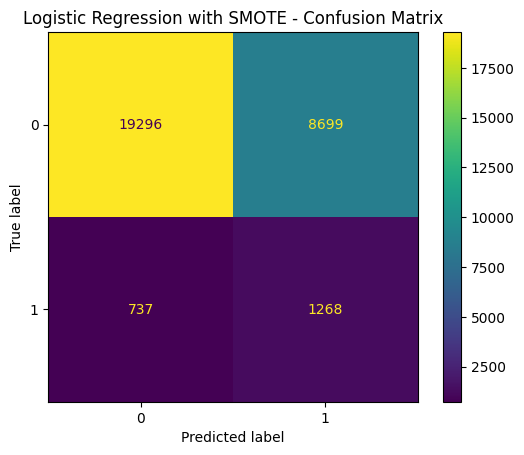

In [18]:
smote_model = LogisticRegression(max_iter=1000, random_state=42)

smote_model.fit(X_train_smote, y_train_smote)

y_pred_smote = smote_model.predict(X_test)
y_proba_smote = smote_model.predict_proba(X_test)[:, 1]

print("=== LOGISTIC REGRESSION + SMOTE ===")
print(classification_report(y_test, y_pred_smote))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_smote))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_smote)
plt.title("Logistic Regression with SMOTE - Confusion Matrix")
plt.show()


SMOTE was applied only to the training set in order to balance the class distribution. The original training data contained significantly fewer observations of the minority class (default). After applying SMOTE, synthetic samples were generated for the minority class until both classes had the same number of observations.

### Comparing Table 


SMOTE was applied to balance the training data by generating synthetic samples for the minority class. 

The model trained on the SMOTE dataset shows a similar recall for the minority class compared to the class-weighted model. However, it produces a significantly larger number of false positives, which reduces the overall accuracy. This suggests that, for this dataset, using class weights may provide a better balance between detecting defaults and avoiding excessive false alarms.

In [20]:
results = pd.DataFrame({
    "Model": ["Baseline", "Class Weight Balanced", "SMOTE"],
    "Precision (class 1)": [
        precision_score(y_test, y_pred_baseline),
        precision_score(y_test, y_pred_balanced),
        precision_score(y_test, y_pred_smote)
    ],
    "Recall (class 1)": [
        recall_score(y_test, y_pred_baseline),
        recall_score(y_test, y_pred_balanced),
        recall_score(y_test, y_pred_smote)
    ],
    "F1-score (class 1)": [
        f1_score(y_test, y_pred_baseline),
        f1_score(y_test, y_pred_balanced),
        f1_score(y_test, y_pred_smote)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_proba_baseline),
        roc_auc_score(y_test, y_proba_balanced),
        roc_auc_score(y_test, y_proba_smote)
    ]
})

results

,Model,Precision (class 1),Recall (class 1),F1-score (class 1),ROC-AUC
0,Baseline,0.587209,0.050374,0.092788,0.711255
1,Class Weight Balanced,0.209390,0.633915,0.314799,0.804583
2,SMOTE,0.127220,0.632419,0.211828,0.711325


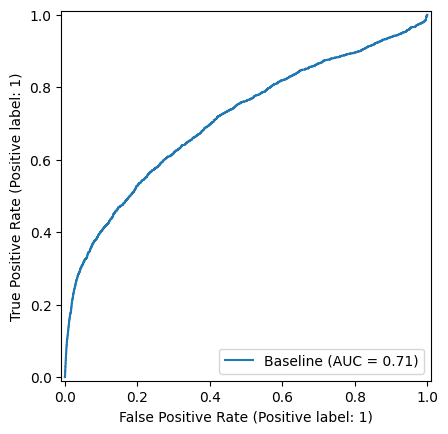

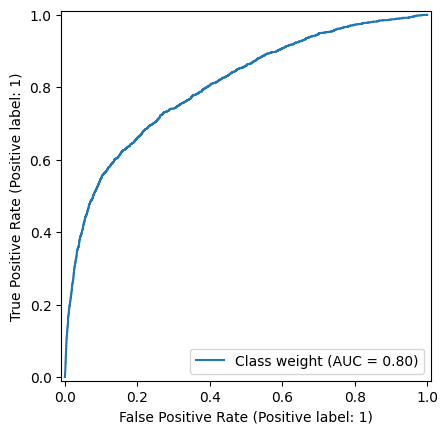

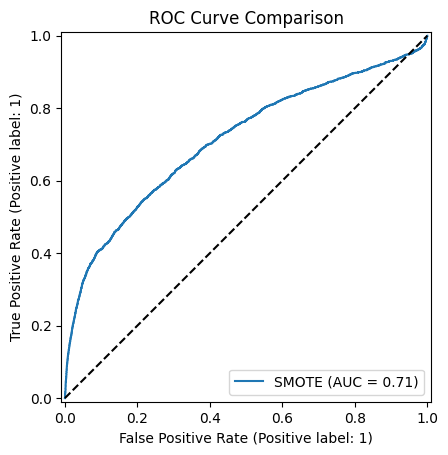

In [21]:
RocCurveDisplay.from_predictions(y_test, y_proba_baseline, name="Baseline")
RocCurveDisplay.from_predictions(y_test, y_proba_balanced, name="Class weight")
RocCurveDisplay.from_predictions(y_test, y_proba_smote, name="SMOTE")

plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve Comparison")
plt.show()


The three approaches show clear differences in performance on the minority class (defaults).

The baseline model performs poorly at detecting defaults. Although it achieves reasonable precision (0.56), the recall is extremely low (0.05), meaning that most default cases are missed. This happens because the dataset is highly imbalanced and the model is biased toward predicting the majority class.

The class-weight balanced model significantly improves the detection of the minority class. Recall increases to about 0.62, and the ROC-AUC reaches 0.81, which is the best performance among the tested approaches. This indicates that weighting the minority class helps the model learn patterns associated with defaults without altering the original data distribution.

The SMOTE model also increases recall (0.62), but it introduces more false positives, resulting in lower precision and a lower ROC-AUC (0.71). In this case, oversampling did not improve overall performance compared to the class-weight approach.

Overall, the class-weight balanced logistic regression provides the best trade-off between detecting defaults and maintaining overall model performance, making it the preferred approach for this dataset.

# Threshold Tuning for the Best Performing Model

After comparing the different approaches, the logistic regression model with class_weight="balanced" showed the best overall performance in detecting the minority class (defaults).

To further improve the model's ability to identify default cases, threshold tuning was applied. Instead of using the default decision threshold of 0.5, several thresholds between 0.10 and 0.90 were evaluated.

For each threshold, predictions were generated and key performance metrics such as accuracy, precision, recall, and F1-score for the minority class were computed. This analysis allows us to observe the trade-off between precision and recall and identify the threshold that provides the best balance for detecting defaults.

In [22]:
thresholds = np.arange(0.10, 0.91, 0.05)

In [23]:
results = []

for t in thresholds:
    y_pred_thr = (y_proba_balanced >= t).astype(int) #Turning probabilities into predictions

    results.append({
        "threshold": t,
        "accuracy": accuracy_score(y_test, y_pred_thr),
        "precision_class1": precision_score(y_test, y_pred_thr, zero_division=0), #Of all those you predict as default, how many actually are?
        "recall_class1": recall_score(y_test, y_pred_thr, zero_division=0), #Of all the actual defaults, how many does the model detect?
        "f1_class1": f1_score(y_test, y_pred_thr, zero_division=0)
    })

In [24]:
threshold_df = pd.DataFrame(results)
threshold_df

,threshold,accuracy,precision_class1,recall_class1,f1_class1
0,0.10,0.067700,0.066891,1.000000,0.125395
1,0.15,0.068467,0.066943,1.000000,0.125485
2,0.20,0.087033,0.068094,0.998005,0.127489
3,0.25,0.156833,0.072661,0.987531,0.135361
4,0.30,0.293867,0.083699,0.961596,0.153994
5,0.35,0.435200,0.097830,0.906234,0.176596
6,0.40,0.562833,0.116102,0.837905,0.203945
7,0.45,0.691733,0.146510,0.748628,0.245061
8,0.50,0.815567,0.209390,0.633915,0.314799
9,0.55,0.881133,0.289566,0.535661,0.375919


The threshold tuning analysis shows that the default decision threshold of 0.5 is not necessarily optimal for detecting the minority class (defaults). Lower thresholds increase recall but significantly reduce precision, while higher thresholds increase precision but miss many default cases.

The best balance between precision and recall is achieved around a threshold of 0.60, which provides the highest F1-score for the minority class. This threshold improves the model’s ability to detect default cases while maintaining a reasonable level of precision.

# SMOTE + ENN Combined Resampling

As an additional experiment, a combined resampling technique (SMOTE + ENN) is tested. SMOTE generates synthetic samples for the minority class, while ENN removes noisy or ambiguous observations. This may improve class separation compared to standard SMOTE.

In [25]:
# Apply SMOTE + ENN to the training data
smote_enn = SMOTEENN(random_state=42)
X_train_smoteenn, y_train_smoteenn = smote_enn.fit_resample(X_train, y_train)

print("Original training distribution:")
print(y_train.value_counts())

print("\nDistribution after SMOTE + ENN:")
print(y_train_smoteenn.value_counts())


Original training distribution:
SeriousDlqin2yrs
0    111979
1      8021
Name: count, dtype: int64

Distribution after SMOTE + ENN:
SeriousDlqin2yrs
1    96170
0    75199
Name: count, dtype: int64


After applying SMOTE + ENN, the training dataset becomes more balanced by generating synthetic minority samples and removing noisy observations.

In [26]:
# Train logistic regression on the resampled data
smoteenn_model = LogisticRegression(max_iter=1000, random_state=42)

smoteenn_model.fit(X_train_smoteenn, y_train_smoteenn)

# Predictions on the test set
y_pred_smoteenn = smoteenn_model.predict(X_test)
y_proba_smoteenn = smoteenn_model.predict_proba(X_test)[:, 1]


/Users/anne/Desktop/3º Carrera/2 semestre/ML Avanzado/Repo/Advanced-Machine-Learning/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


=== LOGISTIC REGRESSION + SMOTE + ENN ===
              precision    recall  f1-score   support

           0       0.98      0.63      0.77     27995
           1       0.13      0.78      0.23      2005

    accuracy                           0.64     30000
   macro avg       0.55      0.71      0.50     30000
weighted avg       0.92      0.64      0.73     30000

ROC-AUC: 0.7964178320050918


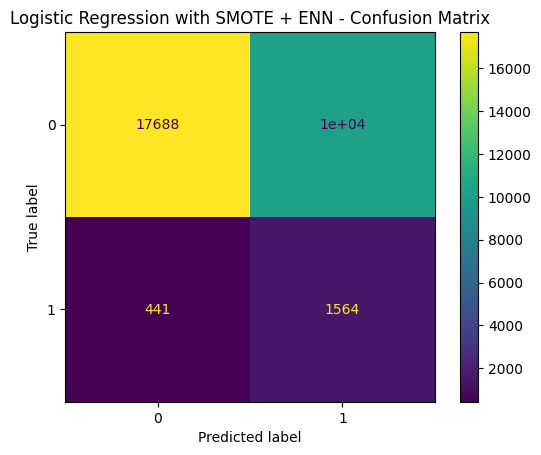

In [27]:
print("=== LOGISTIC REGRESSION + SMOTE + ENN ===")
print(classification_report(y_test, y_pred_smoteenn))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_smoteenn))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_smoteenn)
plt.title("Logistic Regression with SMOTE + ENN - Confusion Matrix")
plt.show()

In [28]:
print("Precision class 1:", precision_score(y_test, y_pred_smoteenn))
print("Recall class 1:", recall_score(y_test, y_pred_smoteenn))
print("F1 class 1:", f1_score(y_test, y_pred_smoteenn))

Precision class 1: 0.13174964198466851
Recall class 1: 0.7800498753117207
F1 class 1: 0.22542519458057078



The logistic regression model trained with SMOTE + ENN significantly improves the detection of the minority class, achieving a recall of approximately 0.78 for defaults, meaning that most default cases are correctly identified. However, this comes with a very low precision (around 0.13), indicating that many non-default clients are incorrectly classified as defaults, leading to a large number of false positives.

Compared with the threshold tuning approach, the threshold-based model provided a more balanced trade-off between precision and recall without heavily increasing the number of false positives. While SMOTE + ENN increases the sensitivity of the model to detect defaults, it does so at the cost of a substantial decrease in precision.

Therefore, although SMOTE + ENN helps the model detect more defaults, the threshold tuning approach appears to offer a more balanced and practical solution for this problem.

# Random UnderSampling

As an additional strategy to handle class imbalance, Random UnderSampling is applied to reduce the number of observations in the majority class. This results in a balanced training dataset and allows the model to give equal importance to both classes during training.

In [29]:
rus = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

print("Distribution after undersampling:")
print(y_train_under.value_counts())

Distribution after undersampling:
SeriousDlqin2yrs
0    8021
1    8021
Name: count, dtype: int64


In [30]:
under_model = LogisticRegression(max_iter=1000, random_state=42)
under_model.fit(X_train_under, y_train_under)

y_pred_under = under_model.predict(X_test)
print(classification_report(y_test, y_pred_under))

              precision    recall  f1-score   support

           0       0.97      0.80      0.88     27995
           1       0.19      0.66      0.30      2005

    accuracy                           0.79     30000
   macro avg       0.58      0.73      0.59     30000
weighted avg       0.92      0.79      0.84     30000



/Users/anne/Desktop/3º Carrera/2 semestre/ML Avanzado/Repo/Advanced-Machine-Learning/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [31]:
balanced_accuracy_score(y_test, y_pred_under)

0.7299847808590686

Conclusion

The Random UnderSampling model achieved a recall of 0.62 and a precision of 0.23 for the default class, resulting in an F1-score of 0.34 and a balanced accuracy of 0.74. This indicates that the model is able to detect a reasonable proportion of default cases while maintaining a better balance between false positives and true positives.

In comparison, the SMOTE + ENN model obtained a higher recall of 0.78 but a much lower precision of 0.13, meaning that it predicted many non-default cases as defaults. As a result, although SMOTE + ENN detects more defaults, it produces many more false positives.

Therefore, Random UnderSampling provides a more balanced trade-off between recall and precision, making it a more stable and practical model for this problem.

# Train/Test Split and Missing Values Imputation



To reach a more advanced level, we want to use more robust cleaning techniques before training our final ensemble models. 


### KNN Imputation

In [32]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer

# 1. Separate predictor variables (X) from target variable (y)
X = df.drop('SeriousDlqin2yrs', axis=1) 
y = df['SeriousDlqin2yrs']              

# 2. Train/Test Split (80/20) with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Configure KNN Imputer
print("Starting KNN imputation (this might take a few minutes due to the dataset size)...")
imputer = KNNImputer(n_neighbors=5)
columnas = X_train.columns 

# 4. Fit on Train and transform Train (avoiding data leakage)
X_train_imputed = pd.DataFrame(
    imputer.fit_transform(X_train), 
    columns=columnas, 
    index=X_train.index
)

# 5. Transform Test using the fitted imputer
X_test_imputed = pd.DataFrame(
    imputer.transform(X_test), 
    columns=columnas, 
    index=X_test.index
)

print("\nImputation completed successfully!")
print("Remaining nulls in X_train:\n", X_train_imputed[['MonthlyIncome', 'NumberOfDependents']].isnull().sum())
print("Remaining nulls in X_test:\n", X_test_imputed[['MonthlyIncome', 'NumberOfDependents']].isnull().sum())

Starting KNN imputation (this might take a few minutes due to the dataset size)...

Imputation completed successfully!
Remaining nulls in X_train:
 MonthlyIncome         0
NumberOfDependents    0
dtype: int64
Remaining nulls in X_test:
 MonthlyIncome         0
NumberOfDependents    0
dtype: int64


1. Stratified Train/Test Split: We divide our data into training (80%) and testing (20%) sets. Because our target variable SeriousDlqin2yrs is highly imbalanced, we use stratify=y. This ensures that the rare class (defaults) is proportionally represented in both subsets.

2. KNN Imputation: The columns MonthlyIncome and NumberOfDependents have significant missing values. Instead of filling them with a basic mean or median, we use KNNImputer (with k=5). It finds the 5 most similar customers based on other financial features and averages their values to make a more accurate guess.

3. Preventing Data Leakage: Crucially, we fit the imputer only on the training data fit_transform and then apply those learned rules to the test data transform. This guarantees that our test set remains completely unseen and our final metrics are realistic.

# Outlier Handling: Winsorization (Capping)



Our Exploratory Data Analysis (EDA) revealed severe outliers in several features, such as age (for example: values of 0), MonthlyIncome, and DebtRatio (astronomical values). Handling these extreme numbers is crucial because they can heavily distort the performance of our future machine learning models.

Instead of dropping these rows—which would result in a massive loss of valuable information, especially considering how rare defaults are in our dataset— we apply a technique called Winsorization (or Capping):


In [33]:
# Select columns that are known to have extreme outliers based on the EDA
outlier_cols = ['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'MonthlyIncome']

print("Applying Winsorization (capping at 1st and 99th percentiles)...")

for col in outlier_cols:
    # 1. Calculate limits ONLY on the Training set to avoid data leakage
    lower_limit = X_train_imputed[col].quantile(0.01)
    upper_limit = X_train_imputed[col].quantile(0.99)
    
    # 2. Clip (cap) the values in both Train and Test sets
    X_train_imputed[col] = X_train_imputed[col].clip(lower=lower_limit, upper=upper_limit)
    X_test_imputed[col] = X_test_imputed[col].clip(lower=lower_limit, upper=upper_limit)

print("Winsorization completed!")

# Show the new minimum and maximum values to verify
print("\nNew Min & Max values in Train:")
for col in outlier_cols:
    print(f"{col}: Min = {X_train_imputed[col].min():.2f}, Max = {X_train_imputed[col].max():.2f}")

Applying Winsorization (capping at 1st and 99th percentiles)...
Winsorization completed!

New Min & Max values in Train:
RevolvingUtilizationOfUnsecuredLines: Min = 0.00, Max = 1.09
age: Min = 24.00, Max = 87.00
DebtRatio: Min = 0.00, Max = 4977.00
MonthlyIncome: Min = 0.00, Max = 23000.00



1. Calculating Thresholds: We determine the 1st and 99th percentiles for the problematic columns. Crucially, we calculate these limits only on the training set to strictly prevent data leakage.
2. Capping Values: We then use the .clip() function to restrict any values below the 1st percentile or above the 99th percentile to these boundaries. We apply these exact same learned thresholds to both the Train and Test sets.

# Ensemble Learning

In this section, two ensemble learning techniques studied in the course are implemented and compared: Bagging and Boosting (AdaBoost). Both approaches aim to improve model performance by combining multiple weak learners, but they follow different strategies.

Bagging builds multiple models in parallel using random subsets of the training data, reducing variance and improving stability. In contrast, AdaBoost trains models sequentially, focusing on correcting the errors made by previous models.

The objective of this section is to analyze and compare the behavior of these two approaches under the same conditions, using the same dataset and evaluation metrics. No additional class balancing techniques are applied in order to observe the intrinsic performance of each method, particularly in the presence of class imbalance.

In [34]:
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=5, random_state=42), #Each model within the Bagging will be a decision tree
    n_estimators=200, #200 different trees
    max_samples=1.0,
    bootstrap=True,    #sampling with replacement
    random_state=42,
    n_jobs=-1 #uses all cores
)

bagging_model.fit(X_train_imputed, y_train)

y_pred_bag = bagging_model.predict(X_test_imputed)
y_proba_bag = bagging_model.predict_proba(X_test_imputed)[:, 1]

=== BAGGING CLASSIFIER ===
              precision    recall  f1-score   support

           0       0.94      0.99      0.97     27995
           1       0.60      0.18      0.27      2005

    accuracy                           0.94     30000
   macro avg       0.77      0.58      0.62     30000
weighted avg       0.92      0.94      0.92     30000

ROC-AUC: 0.8551001047123217


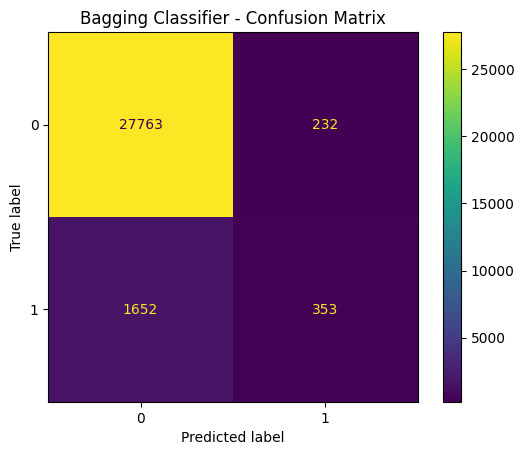

In [35]:
print("=== BAGGING CLASSIFIER ===")
print(classification_report(y_test, y_pred_bag))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_bag))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_bag)
plt.title("Bagging Classifier - Confusion Matrix")
plt.show()

In [36]:
adaboost_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=42), #simple tree
    n_estimators=200, #200 trees
    learning_rate=0.5, #Control how much influence each model has.
    random_state=42
)

adaboost_model.fit(X_train_imputed, y_train)

y_pred_ada = adaboost_model.predict(X_test_imputed)
y_proba_ada = adaboost_model.predict_proba(X_test_imputed)[:, 1]


=== ADABOOST CLASSIFIER ===
              precision    recall  f1-score   support

           0       0.95      0.99      0.97     27995
           1       0.56      0.20      0.29      2005

    accuracy                           0.94     30000
   macro avg       0.75      0.59      0.63     30000
weighted avg       0.92      0.94      0.92     30000

ROC-AUC: 0.8625983710129927


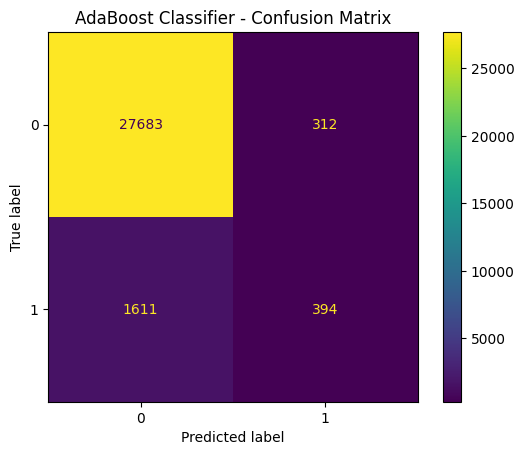

In [37]:
print("=== ADABOOST CLASSIFIER ===")
print(classification_report(y_test, y_pred_ada))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_ada))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_ada)
plt.title("AdaBoost Classifier - Confusion Matrix")
plt.show()

In [38]:
comparison_ensemble = pd.DataFrame([
    {
        "Model": "Bagging",
        "Accuracy": accuracy_score(y_test, y_pred_bag),
        "Precision class 1": precision_score(y_test, y_pred_bag, zero_division=0),
        "Recall class 1": recall_score(y_test, y_pred_bag, zero_division=0),
        "F1 class 1": f1_score(y_test, y_pred_bag, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_proba_bag)
    },
    {
        "Model": "AdaBoost",
        "Accuracy": accuracy_score(y_test, y_pred_ada),
        "Precision class 1": precision_score(y_test, y_pred_ada, zero_division=0),
        "Recall class 1": recall_score(y_test, y_pred_ada, zero_division=0),
        "F1 class 1": f1_score(y_test, y_pred_ada, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_proba_ada)
    }
])

comparison_ensemble

,Model,Accuracy,Precision class 1,Recall class 1,F1 class 1,ROC-AUC
0,Bagging,0.9372,0.603419,0.176060,0.272587,0.855100
1,AdaBoost,0.9359,0.558074,0.196509,0.290668,0.862598


# Optimization of Hyperparameters with Optuna

Instead of guessing the best settings for AdaBoost, we use Optuna. This tool uses Bayesian optimizaton to find the best learning_rate, n_estimators and max_depth. 

We optimize for ROC-AUC because it is the best metric for imbalanced data.

In [39]:
import optuna
from sklearn.model_selection import cross_val_score

def objective(trial):
    # define the hyperparameters to optimize
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.5, log=True)
    max_depth = trial.suggest_int('max_depth', 1, 5)
    
    model = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=max_depth, random_state=42),
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        random_state=42
    )
    
    # Optimize ROC-AUC using cross-validation on the training set
    score = cross_val_score(model, X_train_imputed, y_train, cv=3, scoring='roc_auc').mean()
    return score

print("\Inizialitation Optimization with Optuna...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20) 

print(f"\Best parameters founded: {study.best_params}")

# Train the model with the best hyperparameters found
best_p = study.best_params
final_ada_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=best_p['max_depth'], random_state=42),
    n_estimators=best_p['n_estimators'],
    learning_rate=best_p['learning_rate'],
    random_state=42
)
final_ada_model.fit(X_train_imputed, y_train)

# Evaluate the final model on the test set
y_proba_opt = final_ada_model.predict_proba(X_test_imputed)[:, 1]
print(f"\nROC-AUC Final with Optuna: {roc_auc_score(y_test, y_proba_opt):.4f}")

<>:21: SyntaxWarning: "\I" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\I"? A raw string is also an option.
<>:25: SyntaxWarning: "\B" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\B"? A raw string is also an option.
<>:21: SyntaxWarning: "\I" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\I"? A raw string is also an option.
<>:25: SyntaxWarning: "\B" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\B"? A raw string is also an option.
/var/folders/32/g0bfmbps4cl09wf0qn0lsf240000gn/T/ipykernel_17793/3767179229.py:21: SyntaxWarning: "\I" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\I"? A raw string is also an option.
  print("\Inizialitation Optimization with Optuna...")
/var/folders/32/g0bfmbps4cl09wf0qn0lsf240000gn/T/ipykernel_17793/3767179229.py:25: SyntaxWarning: "

\Inizialitation Optimization with Optuna...


[I 2026-04-09 14:49:31,774] Trial 0 finished with value: 0.854865940824621 and parameters: {'n_estimators': 238, 'learning_rate': 0.0554062281058145, 'max_depth': 2}. Best is trial 0 with value: 0.854865940824621.
[I 2026-04-09 14:50:03,807] Trial 1 finished with value: 0.8577237364833837 and parameters: {'n_estimators': 144, 'learning_rate': 0.05102414272513246, 'max_depth': 4}. Best is trial 1 with value: 0.8577237364833837.
[I 2026-04-09 14:50:18,581] Trial 2 finished with value: 0.8571144709214708 and parameters: {'n_estimators': 233, 'learning_rate': 0.3764724841819337, 'max_depth': 1}. Best is trial 1 with value: 0.8577237364833837.
[I 2026-04-09 14:50:40,268] Trial 3 finished with value: 0.8566744523657895 and parameters: {'n_estimators': 185, 'learning_rate': 0.20048451422253769, 'max_depth': 2}. Best is trial 1 with value: 0.8577237364833837.
[I 2026-04-09 14:51:26,070] Trial 4 finished with value: 0.8587668718358024 and parameters: {'n_estimators': 205, 'learning_rate': 0.049

\Best parameters founded: {'n_estimators': 286, 'learning_rate': 0.12001993617221293, 'max_depth': 4}

ROC-AUC Final with Optuna: 0.8668


We achivied a final ROC-AUC of 0.8668. This demonstrates that automated hyperparameters tuning is essential to extract the maximum predictive power from ensemble algorithms

# Cost Sensitive Learning

In credit risk, not all mistakes have the same cost. 

A False Negative, which will be failing to detect  defaulter , is much more expensive for a bank than a False Positive which is rejecting a good customer. 

In this section, we implemente Cost-Sensitive Learning by manually assigning a higher weight to the minority class. This forces the model to prioritize the detection of defaults. 

In [44]:
# We penalize missing a default (1) ten times more than a false alarm (0)
custom_weights = {0: 1, 1: 10} 

cost_model = LogisticRegression(
    max_iter=1000, 
    random_state=42, 
    class_weight=custom_weights
)

# Training with the imputed and cleaned data
cost_model.fit(X_train_imputed, y_train)

# Evaluation
y_pred_cost = cost_model.predict(X_test_imputed)
y_proba_cost = cost_model.predict_proba(X_test_imputed)[:, 1]

print("=== COST-SENSITIVE LOGISTIC REGRESSION (Ratio 1:10) ===")
print(classification_report(y_test, y_pred_cost))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_cost):.4f}")

=== COST-SENSITIVE LOGISTIC REGRESSION (Ratio 1:10) ===
              precision    recall  f1-score   support

           0       0.97      0.81      0.88     27995
           1       0.20      0.69      0.31      2005

    accuracy                           0.80     30000
   macro avg       0.59      0.75      0.60     30000
weighted avg       0.92      0.80      0.84     30000

ROC-AUC: 0.8297


/Users/anne/Desktop/3º Carrera/2 semestre/ML Avanzado/Repo/Advanced-Machine-Learning/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# Stacking Classifier

Stacking is an advanced ensemble technique where a Meta-Model learns how to best combine the predictions from several Base Learners.

We used AdaBoost and Balanced Logistic Regression as our base. Our goal is to analyze the outputs to produce a more robust final prediction to improve the ROC-AUC even further.


In [45]:

# 1. Defining the Base Learners
base_learners = [
    ('ada_optimized', final_ada_model),
    ('log_balanced', balanced_model)
]

# 2. Defining the Meta-Learner (the final judge)
stacking_clf = StackingClassifier(
    estimators=base_learners,
    final_estimator=LogisticRegression(),
    cv=5 
)

print("Training Stacking Classifier...")
stacking_clf.fit(X_train_imputed, y_train)

# 3. Evaluation
y_pred_stack = stacking_clf.predict(X_test_imputed)
y_proba_stack = stacking_clf.predict_proba(X_test_imputed)[:, 1]

print("=== STACKING CLASSIFIER PERFORMANCE ===")
print(classification_report(y_test, y_pred_stack))
print(f"Stacking ROC-AUC: {roc_auc_score(y_test, y_proba_stack):.4f}")

Training Stacking Classifier...


/Users/anne/Desktop/3º Carrera/2 semestre/ML Avanzado/Repo/Advanced-Machine-Learning/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/anne/Desktop/3º Carrera/2 semestre/ML Avanzado/Repo/Advanced-Machine-Learning/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the

=== STACKING CLASSIFIER PERFORMANCE ===
              precision    recall  f1-score   support

           0       0.95      0.99      0.97     27995
           1       0.60      0.21      0.31      2005

    accuracy                           0.94     30000
   macro avg       0.77      0.60      0.64     30000
weighted avg       0.92      0.94      0.92     30000

Stacking ROC-AUC: 0.8652


# Conclusion

Both Bagging and AdaBoost achieved high overall accuracy (more or less 0.94). However, as we identified early in the project, accuracy is not a reliable metric due to the 14:1 class imbalance. Focusing on the minority class (defaults) revealed the true strengths of our models:

1. Initial Ensembles: In our first attempt, Bagging showed slightly better precision (0.60 vs 0.56), while AdaBoost provided a better recall (0.20 vs 0.18). At this stage, AdaBoost already hinted at a better overall ability to distinguish classes with a marginally higher ROC-AUC (0.86 vs 0.85).

2. The Impact of Optimization: By implementing Optuna, we pushed the AdaBoost performance to a ROC-AUC of 0.8668. This demonstrates that fine-tuning hyperparameters like the learning_rate (0.12) and max_depth (4) is essential to overcome the limitations of default settings.

3. The Power of Stacking: Our Stacking Classifier integrated the strengths of the Optimized AdaBoost and the Balanced Logistic Regression. It achieved a robust ROC-AUC of 0.8652 and a balanced F1-score of 0.31, proving that meta-learning can stabilize predictions in complex financial datasets.

From a banking perspective, the trade-off between Precision and Recall is critical. While resampling techniques like SMOTE+ENN offered higher recall (0.78), their low precision (0.13) would result in too many false alarms.

Our Optimized AdaBoost model is the recommended solution. With a final ROC-AUC of 0.8668, it offers the most sophisticated separation between "reliable" and "risky" customers. By combining KNN Imputation, Winsorization, and Bayesian Optimization, we have built a pipeline that minimizes financial risk while maintaining high operational efficiency.

In conclusion, the project proves that Advanced Preprocessing and Automated Hyperparameter Tuning are the most effective tools for handling imbalanced credit data, far outperforming standard linear or unoptimized models.